### Importing libraries needed

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## **1 Data**

## **1A** Each row of csvImages 10k x 784.csv contains the grayscale values of a 28×28 image. Load this data into a pandas DataFrame and convert it to a NumPy array using pandas.values. Print the shape of the data

In [4]:
# Load the dataset using pandas method
df = pd.read_csv("csvImages 10k x 784.csv", header=None)

# Convert the DataFrame to a NumPy array
data = df.values

print("Data shape:", data.shape)

Data shape: (10000, 784)


## **1B**

### Normalize the values by dividing by 255. To display the images, reshape each array to 28×28 using numpy.ndarray.reshape. Use matplotlib.pyplot.imshow and matplotlib.pyplot.subplot to plot the first five images using the 'gray' colormap.

In [5]:
# Normalize the Data
data_norm = data.astype("float32") / 255.0
print("Min:", data_norm.min(), "Max:", data_norm.max())

Min: 0.0 Max: 1.0


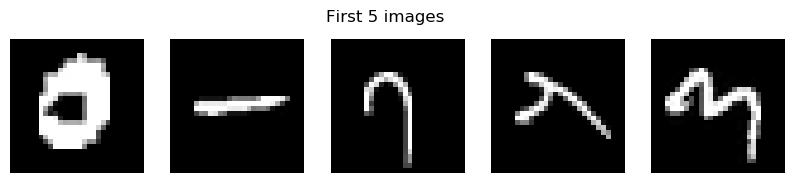

In [6]:
# Reshape and Show first 5 images (28x28)
images = data_norm.reshape(-1, 28, 28)

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.axis("off")
plt.suptitle("First 5 images")
plt.show()


## **1C**

## To prepare the data for input to the neural network, reshape each image back into a one-dimensional array of size 784.

In [7]:
# Flatten the image back to one-dimensional array (784) for neural network
X = data_norm.reshape(-1, 784)
print("Input to network shape:", X.shape)

Input to network shape: (10000, 784)


## **2 Modelling** 

## **2A**

## Use keras.layers to create an input layer matching the dimensions of your data.

In [9]:
# Create data  dimensions
input_dim = 784
encoding_dim = 64  # < 50% of 784

# Input layer
input_img = Input(shape=(input_dim,))


## **2B**

### Use keras.layers to create an encoding stage with at least two layers that reduces the data size to 50% or less (smaller is better). Choose appropriate activation functions.

In [10]:
# Encoding stage (at least two layers)
encoded = Dense(256, activation="relu")(input_img)
encoded = Dense(encoding_dim, activation="relu")(encoded)

## 2C

## Use keras.layers to create a decoding stage with at least two layers that restores the data to its original size. Choose appropriate activation functions.

In [11]:
# Decoding stage (at least two layers)
decoded = Dense(256, activation="relu")(encoded)
decoded = Dense(input_dim, activation="sigmoid")(decoded)


## 2D Compile the complete autoencoder network, selecting a suitable loss function and optimizer, and train the network on the image data. 

In [12]:
# compile the autoencoder
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(
    X, X,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    shuffle=True
)


Instructions for updating:
Use tf.cast instead.
Train on 9000 samples, validate on 1000 samples
Instructions for updating:
Use tf.cast instead.
Epoch 1/30
9000/9000 [==============================] - 1s 119us/sample - loss: 0.1062 - val_loss: 0.0686
Epoch 2/30
9000/9000 [==============================] - 1s 73us/sample - loss: 0.0617 - val_loss: 0.0580
Epoch 3/30
9000/9000 [==============================] - 1s 76us/sample - loss: 0.0522 - val_loss: 0.0499
Epoch 4/30
9000/9000 [==============================] - 1s 75us/sample - loss: 0.0451 - val_loss: 0.0431
Epoch 5/30
9000/9000 [==============================] - 1s 64us/sample - loss: 0.0390 - val_loss: 0.0370
Epoch 6/30
9000/9000 [==============================] - 1s 61us/sample - loss: 0.0338 - val_loss: 0.0326
Epoch 7/30
9000/9000 [==============================] - 1s 65us/sample - loss: 0.0302 - val_loss: 0.0300
Epoch 8/30
9000/9000 [==============================] - 1s 69us/sample - loss: 0.0282 - val_loss: 0.0283
Epoch 9/30
9000

## 2E Compile the encoder network using your trained input layer and encoding stage. 

In [13]:
# Encoder model and summary
encoder = Model(input_img, encoded)
encoder.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         (None, 784)               0         
_________________________________________________________________
dense_4 (Dense)              (None, 256)               200960    
_________________________________________________________________
dense_5 (Dense)              (None, 64)                16448     
Total params: 217,408
Trainable params: 217,408
Non-trainable params: 0
_________________________________________________________________


In [14]:
autoencoder.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         (None, 784)               0         
_________________________________________________________________
dense_4 (Dense)              (None, 256)               200960    
_________________________________________________________________
dense_5 (Dense)              (None, 64)                16448     
_________________________________________________________________
dense_6 (Dense)              (None, 256)               16640     
_________________________________________________________________
dense_7 (Dense)              (None, 784)               201488    
Total params: 435,536
Trainable params: 435,536
Non-trainable params: 0
_________________________________________________________________


## **3 Conclusions** 

## 3A Use matplotlib.plot.imshow, matplotlib.plot.subplot, and your trained models to plot the first five original images along the top row, the encoded versions along the second row, and the decoded versions along the bottom row.

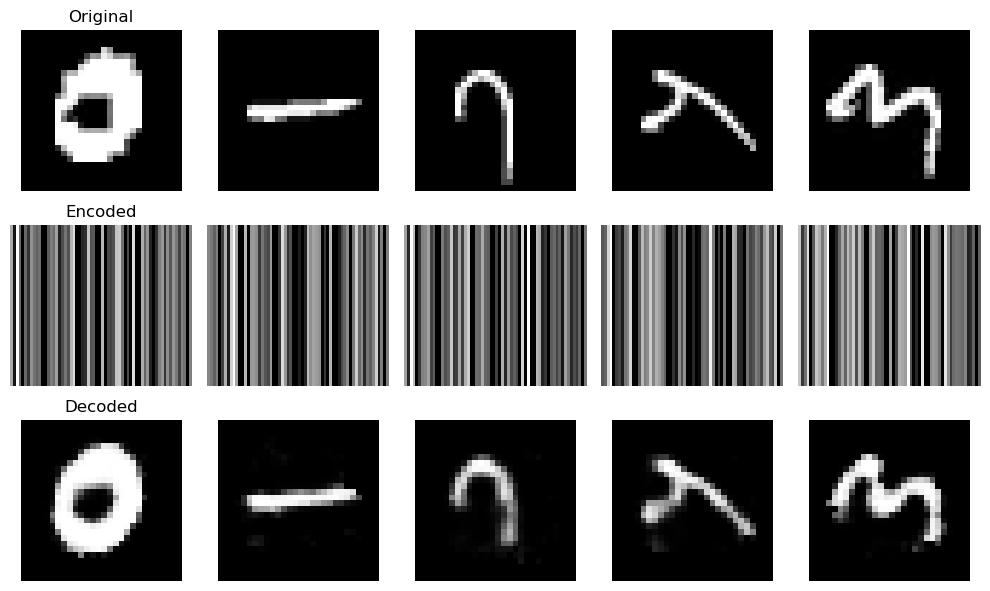

In [15]:
# Plot top 5 original, encoded, decoded first five images


n = 5
X_sample = X[:n]

encoded_imgs = encoder.predict(X_sample)
decoded_imgs = autoencoder.predict(X_sample)

plt.figure(figsize=(10, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_sample[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original")

    # Encoded (1D visualization)
    ax = plt.subplot(3, n, i + 1 + n)
    enc = encoded_imgs[i]
    enc_norm = (enc - enc.min()) / (enc.max() - enc.min() + 1e-8)
    plt.imshow(enc_norm.reshape(1, -1), cmap="gray", aspect="auto")
    plt.axis("off")
    if i == 0:
        ax.set_title("Encoded")

    # Decoded
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Decoded")

plt.tight_layout()
plt.show()


## **3B**

## Adjust the hyperparameters of your model as needed to produce decoded images that closely represent the originals while minimizing the encoding size. Record all adjustments in Markdown.

## Hyperparameter Adjustments

### Initial Model
- Encoding dimension: 64
- Hidden layers: 256 → 64 → 256
- Activation functions: ReLU (hidden), Sigmoid (output)
- Optimizer: Adam (lr = 0.001)
- Loss: MSE
- Epochs: 30
- Batch size: 256

### Adjustment 1
- Increased epochs from 30 → 50  
**Result:** Lower reconstruction loss, smoother decoded images.

### Adjustment 2
- Reduced encoding dimension from 64 → 32  
**Result:** Higher compression but slightly blurrier reconstructions.

### Final Choice
- Encoding dimension: 64  
- Epochs: 40  
This gave the best balance between compression and image quality.

## **3C**

## Describe in Markdown how well the autoencoder is performing, referencing the plots.

## Autoencoder Performance

The decoded images closely resemble the original handwritten digits. The overall shapes, strokes, and digit structure are preserved, although some fine details appear slightly smoothed. The encoded representations are highly compressed but still contain enough information for the decoder to reconstruct recognizable digits.

Overall, the autoencoder performs well: the reconstructed digits are clear and identifiable, demonstrating that the model successfully learned a compact representation of the data.

## 3D Calculate the amount of data needed to store a single image, assuming a floating-point number requires 4 bytes. Compute the percentage of memory saved using your encoding.

In [16]:


encoding_dim = encoded_imgs.shape[1]  # e.g., 64
bytes_per_float = 4

original_bytes = 784 * bytes_per_float
encoded_bytes = encoding_dim * bytes_per_float

memory_saved = original_bytes - encoded_bytes
percent_saved = (memory_saved / original_bytes) * 100

print("Original size per image:", original_bytes, "bytes")
print("Encoded size per image:", encoded_bytes, "bytes")
print("Memory saved:", memory_saved, "bytes")
print(f"Percentage saved: {percent_saved:.2f}%")

Original size per image: 3136 bytes
Encoded size per image: 256 bytes
Memory saved: 2880 bytes
Percentage saved: 91.84%


## GROUP MEMBERS:
- Femi Ajayi
- Olaitan Faniran